<font size = "5"> **Day 2: [Electron Diffraction and 4D STEM](../MLSTEM2026.ipynb)** </font>

<hr style="height:1px;border-top:4px solid #FF8200" />


[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day2/09AM_Basic_Diffraction.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day2/09AM_Basic_Diffraction.ipynb)



# Basics of Diffraction
Lecturer: Gerd Duscher

part of the workshop of 

<font size = "5"> **[Machine Learning in Scanning Transmission Electron Microscopy](../_MLSTEM2025.ipynb)**</font>


**Day2: Electron Diffraction, 4D-STEM, Differential Phase Contrast
Encoder**
<table style="margin-right:auto;margin-left:0px">
  <tr>
    <td>Gerd Duscher </td>
    <td>Sergei Kalinin</td>
  </tr>
  <tr>
    <td colspan="2"><center>Microscopy Facilities</td> 
  </tr>
  
  <tr>
    <td colspan="2"><center>Materials Science & Engineering</td>
    <td></td>
  </tr>
  <tr>
    <td colspan="2"><center>Institute of Advanced Materials & Manufacturing</td>
  </tr>
  <tr>
    <td colspan="2"><center> The University of Tennessee, Knoxville</center> </td>
  </tr>
</table>
        
**June 2026**

## Overview
We will go over all the different parts of an electron diffraction pattern and how to simulate them with kinematic theory.
Dig out your geometry and let's see what we can do with those Bragg Peaks.

- Geometry of scattering and Ewald sphere construction
- Definfition of **excitation error** and its importance
- Simulation and plotting of diffraction pattern
 

## Load packages
### Check for Newest Versions
The next code cell has to be run on Google Colab

On Google Colab: Restart the Session under the "Runtime" menu

In [1]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

if test_package('pyTEMlib') < '0.2026.6.0':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install  --upgrade pyTEMlib -q

print('done')

done


### Load the plotting and figure packages
Import the python packages that we will use:

Beside the basic numerical (numpy) and plotting (pylab of matplotlib) libraries,
* three dimensional plotting
and some libraries from the book
* pyTEMlib for kinematic scattering library.

The pyTEMlib *diffraction_tools* are based on the  **atomic form factors** from Kirklands book

In [2]:
%matplotlib widget
import matplotlib 
import matplotlib.pyplot as plt
import numpy as np

import sys
if 'google.colab' in sys.modules:
    from google.colab import output
    output.enable_custom_widget_manager()    

# additional package 
import itertools 
import scipy

# Import libraries from the book
import pyTEMlib
    
# it is a good idea to show the version numbers at this point for archiving reasons.
__notebook_version__ = '2026.06.19'
print('pyTEM version: ', pyTEMlib.__version__)
print('notebook version: ', __notebook_version__)

pyTEM version:  0.2026.6.0
notebook version:  2026.06.19


## Bragg's Law and Ewald Sphere

$$ \Large
2d \sin{\theta} = n \lambda
$$

with:
- d: interplanar spacing
- $\theta$: Bragg angle
- $\lambda$: wavelength

The origin of Bragg's law is most conveniently explained in real space, but we want to understand the Ewald sphere construction, one of the most omportant concepts in diffraction.

real space | reciprocal space | wave vectors | shifted wave vectors | Ewald sphere
- | - | - | - | -


<img src="images/Bragg-1.jpg" alt="Bragg's Law" width="200" >|<img src="images/Bragg-3.jpg" alt="Bragg's Law" width="200" >|<img src="images/Bragg-4.jpg" alt="Bragg's Law" width="200" >|<img src="images/Bragg-5.jpg" alt="Bragg's Law" width="200" >|<img src="images/Bragg-6.jpg" alt="Bragg's Law" width="200" >

## Reciprocal Space


### Define silicon crystal

In [5]:
#Initialize the dictionary with all the input
atoms = pyTEMlib.crystal_tools.structure_by_name('Silicon')

print(atoms)
print(atoms.get_scaled_positions())

import ase.visualize
ase.visualize.view(atoms*[4,4,1], viewer='x3d')


Lattice(symbols='Si8', pbc=True, cell=[5.43088, 5.43088, 5.43088])
[[0.   0.   0.  ]
 [0.25 0.25 0.25]
 [0.5  0.5  0.  ]
 [0.75 0.75 0.25]
 [0.5  0.   0.5 ]
 [0.75 0.25 0.75]
 [0.   0.5  0.5 ]
 [0.25 0.75 0.75]]


### Wavelength and Magnitude of Incident Wavevector

In [6]:
acceleration_voltage_V = 200.0 *1000.0 #V

wave_length_A  = pyTEMlib.utilities.get_wavelength(acceleration_voltage_V, unit='A')

print('The wavelength for {0:.1f}kV is : {1:.5f}pm'.format(acceleration_voltage_V/1000.,wave_length_A*100.))

wave_vector_magnitude = 1/wave_length_A
K0_magnitude = wave_vector_magnitude

print('The magnitude of the incident wavevector is {0:.2f} 1/nm'.format(K0_magnitude*10) )

The wavelength for 200.0kV is : 2.50793pm
The magnitude of the incident wavevector is 398.73 1/nm


### Reciprocal Lattice and Incident Wavevector

We use ase to invert the unit_cell "matrix" to get the reciprocal cell

And we calculate the incident wave vector from 
- this reciprocal cell, 
- Miller indices of the zone axis and  
- wavelength

In [7]:
zone = [0, 0, 1] #Parallel to z-axis for simplicity

# Reciprocal Lattice 
#  We use ase to invert the unit_cell "matrix"
reciprocal_lattice = atoms.cell.reciprocal() # transposed of inverted unit_cell: np.linalg.inv(atoms.cell]).T

print('reciprocal lattice\n', reciprocal_lattice)

# Incident wavevector in vacuum 
# zone axis in global coordinate system
zone_vector = np.dot(zone, reciprocal_lattice)
K0_unit_vector = zone_vector / np.linalg.norm(zone_vector) # incident unit wave vector 
K0_vector = K0_unit_vector * K0_magnitude

print('Incident wavevector: ',K0_vector,' in units of [1/Ang]')

reciprocal lattice
 Cell([0.18413222166573373, 0.18413222166573373, 0.18413222166573373])
Incident wavevector:  [ 0.         0.        39.8734569]  in units of [1/Ang]


### 2D Plot of Unit Cell in Reciprocal Space

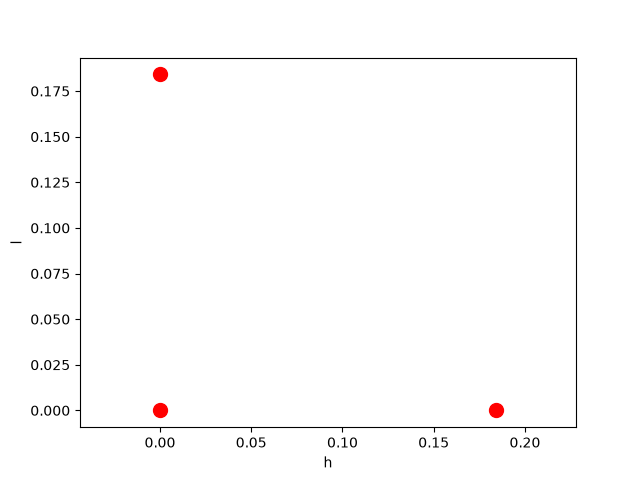

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(reciprocal_lattice[:,0], reciprocal_lattice[:,2], c='red', s=100)
plt.xlabel('h')
plt.ylabel('l')
ax.axis('equal');

### 2D plot of Reciprocal Lattice

Now we get all possible Miller (negative and positive) indices up to a maximum value 

We do get those combination with the itertool package.

In [9]:
hkl_max = 9
indices = np.linspace(-hkl_max,hkl_max, 2*hkl_max+1)   # all evaluated single Miller Indices
hkl = np.array(list(itertools.product(indices, indices, indices))) # all evaluated Miller indices

# Plot 2D
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(hkl[:,0], hkl[:,2], c='red', s=100)
plt.xlabel('h')
plt.ylabel('l')
ax.axis('equal')

(np.float64(-9.9), np.float64(9.9), np.float64(-9.9), np.float64(9.9))

### Origin and Laue Zones
We really do not need that many reflections in the z-direction, so we reduce those.

We chose a spot in a reciprocal lattice (3 dimensional, but we usually draw only a two dimensional projection), where we let `end` the incident wavevector $\vec{k}_I$. 



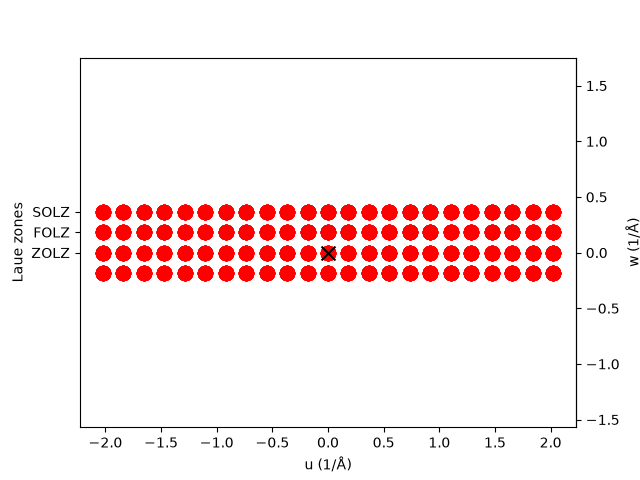

In [10]:
hkl_max = 11
indices_u_v  = np.linspace(-hkl_max, hkl_max, 2*hkl_max+1)  # all evaluated single Miller Indices
indices_w =  np.linspace(-1, 2,4)  # all evaluated single Miller Indices 
hkl  = np.array(list(itertools.product(indices_u_v, indices_u_v, indices_w))) # all evaluated Miller indices

g = np.dot(hkl, reciprocal_lattice) # all evaluated reciprocal lattice points

# Plot 2D
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(g[:,0], g[:,2], c='red', s=100)
ax.axis('equal')
secax_y = ax.secondary_yaxis('right')
secax_y.set_ylabel('w (1/Å)')
ax.set_yticks(g[1:4,2])
ax.set_yticklabels(['ZOLZ', 'FOLZ', 'SOLZ'])
plt.xlabel('u (1/Å)')
plt.ylabel('Laue zones') 
ax.scatter(0, 0, c='black', s=100, marker='x');

Here we defined the `Laue zones` (look at the right for the lables of the w-axis).
You are most familiar with the ``Zero Order Laue Zone (ZOLZ)``, the only Laue zone reachable with X-rays.

However the reciprocal lattice points do not lay only in one plane and so other orders exist as well.
These other planes are called ``Higher Order Laue Zones or HOLZ``.

the first few higher order Laue zones have extra names:
- FOLZ: first order Laue zone
- SOLZ: second order Laue zone

In electron diffraction these planes can diffract and so we need to consider them, moreover, they allow for very precise measurements.

### Ewald Sphere


The origin of the reciprocal lattice is defined as above as the end point of the wave-vector $\vec{k}_I$.
The length of $\vec{k}_I$ is given by the energy of the beam or the reciprocal of the wave_length (we are n reciprocal space). 

Because all diffracted wave vectors $\vec{k}_D$ have to have the same length in elastic scattering, they have to end at the sphere, whose center is the beginning of the incident wave vector. 

This sphere is called Ewald sphere and gives us all possible diffracted wave vectors.

For a short explanation of Braggs Law and Ewald sphere construction please see the *top of this notebook*

Below we show the difference the wavelength makes on size of the Ewald sphere for electron  and X-ray diffraction.
Please ``zoom in`` to the reciprocal lattice to see clearly the difference between X-ray and electron diffraction.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


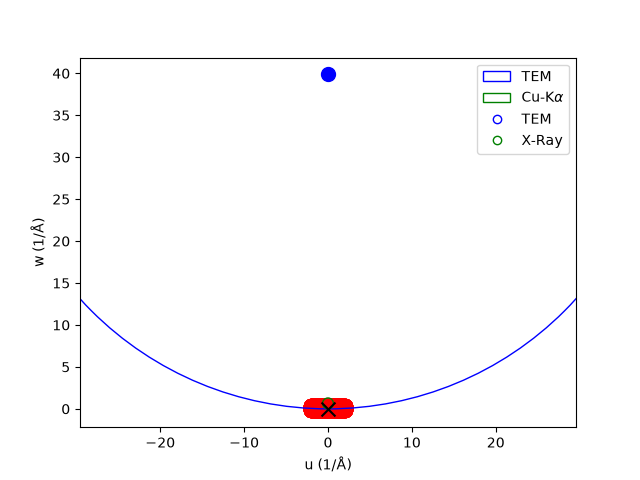

In [16]:
Ewald_Sphere  = plt.Circle((0, K0_magnitude), K0_magnitude, color='b', fill=False, label='TEM')
Ewald_Sphere_CuKa  = plt.Circle((0, 1./1.5418), 1./1.5418, color='g', fill=False,  label=r'Cu-K$\alpha$')

# Plot 2D
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(g[:,0], g[:,2], c='red',s=100)
ax.scatter(0, K0_magnitude, c='blue',s=100)

ax.add_artist(Ewald_Sphere)
ax.add_artist(Ewald_Sphere_CuKa)
ax.scatter(0, 0, c='black', s=100, marker='x');
ax.axis('equal')
plt.xlabel('u (1/Å)')
plt.ylabel('w (1/Å)');
line1 = plt.plot([-300], [0], color="white", marker='o', markerfacecolor="white", markeredgecolor="blue", label='TEM')
line2 = plt.plot([-300], [0], color="white", marker='o', markerfacecolor="white", markeredgecolor="green", label='X-Ray')
line3 = plt.plot([-300], [0], color="white", marker='o', markerfacecolor="white", markeredgecolor="white", linewidth = 3)
plt.legend()
plt.xlim(-15,15);

- Only if a wave vector hits a reciprocal lattice point is the Bragg condition fulfilled and we will get an intensity. Therefore, we look where the Ewald sphere cuts one of the reciprocal lattice points.
- Higher order Laue zone (HOLZ) excitations are due to diffraction from reciprocal lattice planes that are not the one the incident scattering vector end. These excitations are possible as soon as we have an Ewald sphere much larger than the inter{atom reciprocal lattice vector.  The most prominent HOLZ features in a diffraction pattern are the so called HOLZ rings. We will learn later how to use the HOLZ rings to extract information.

### Tilting

Mathematically it is equivalent to tilt the reciprocal lattice or the Ewald Sphere.

Tilting is the way to achieve exact Bragg conditions.

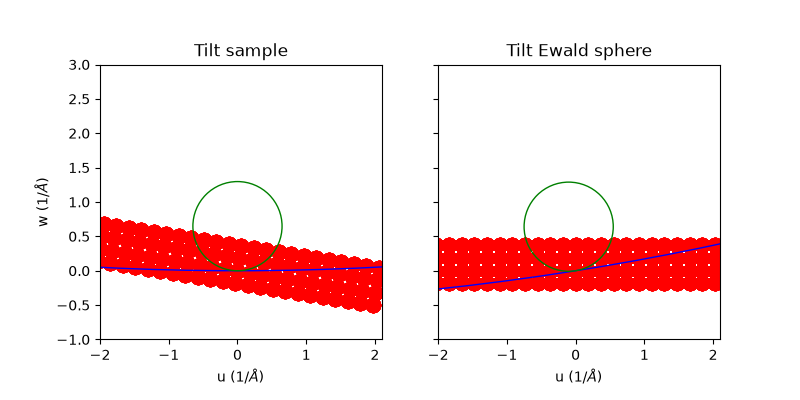

In [17]:
# ----Input ----
tilt_angle = 9.  # in degree
# --------------

tilt_angle_r = np.radians(tilt_angle)  # now in radians
rotation_matrix = np.array([[np.cos(tilt_angle_r), -np.sin(tilt_angle_r)],
                            [np.sin(tilt_angle_r), np.cos(tilt_angle_r)]])
K0_tilt = np.dot([0, K0_magnitude], rotation_matrix)
K_xray_tilt = np.dot([0, 1./1.5418], rotation_matrix)

g_tilt = g[:, [0, 2]].copy()
g_tilt  = np.dot(g_tilt, rotation_matrix)

Ewald_Sphere  = plt.Circle((0, K0_magnitude), K0_magnitude, color='b', fill=False, label='TEM')
Ewald_Sphere_CuKa  = plt.Circle((0, 1/1.5418), 1/1.5418, color='g', fill=False,  label='Cu-K$\alpha$')
Ewald_Sphere_tilt  = plt.Circle((-K0_tilt[0], K0_tilt[1]), K0_magnitude, color='b', fill=False, label='TEM')
Ewald_Sphere_CuKa_tilt  = plt.Circle((-K_xray_tilt[0], K_xray_tilt[1]),  1./1.5418, color='green', fill=False, label='TEM')

fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 4))
ax1.scatter(0, K0_magnitude, c='blue',s=100)
ax1.scatter(g_tilt [:,0], g_tilt [:,1], c='red',s=100)
ax1.add_artist(Ewald_Sphere)
ax1.add_artist(Ewald_Sphere_CuKa)
ax1.set_aspect('equal')
ax1.set_xlabel('u (1/$\\AA$)')
ax1.set_ylabel('w (1/$\\AA$)');
ax1.set_title('Tilt sample')

ax2.scatter(g[:,0], g[:,2], c='red',s=100)
ax2.scatter(-K0_tilt[0], K0_tilt[1], c='blue',s=100)
ax2.add_artist(Ewald_Sphere_tilt)
ax2.add_artist(Ewald_Sphere_CuKa_tilt)
ax2.set_xlabel('u (1/$\\AA$)')
ax2.set_aspect('equal')

ax2.set_title('Tilt Ewald sphere')
ax1.set_xlim(-2, 2.1)
ax1.set_ylim(-1, 3);


### Precise Bragg Condition

The precise Bragg condition is important in X-ray Diffraction and is the reason for the $\theta - 2\theta$ scans in X-ray diffraction experiments. 

The precise Bragg condition will become important in section of conventional TEM (two beam condition).

Obviously, angles are too small for acceleration voltages used in a TEM to show nicely in a graph.
Reduce the acceleration voltage to about 1000 to see a decent graphic with larger angles (why?).

The wavelength for 1.0kV is : 38.76403pm
Reflection [8, 0, 0] with magnitude of reciprocal vector 1.47 1/A  has the Bragg angle 16.6°


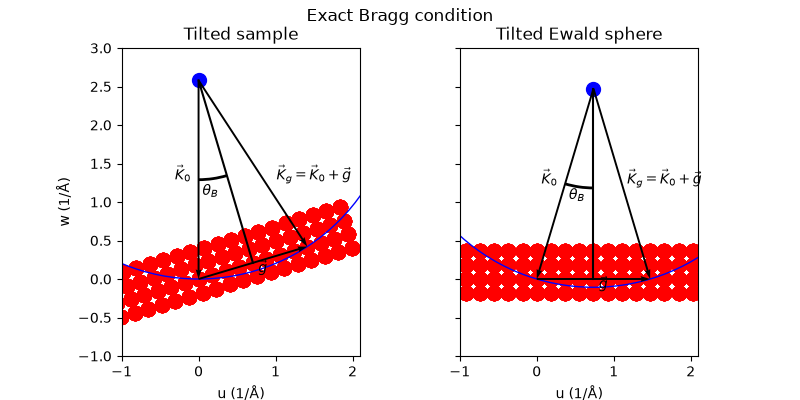

In [27]:

# -----Input -------
Miller_index_h = 8
acceleration_voltage_V = 1.0*1000.0 #V
# ---------------------

hkl_g=[Miller_index_h, 0, 0]
wave_length_A  = pyTEMlib.utilities.get_wavelength(acceleration_voltage_V, unit='A')

print(f'The wavelength for {acceleration_voltage_V/1000:.1f}kV is : {wave_length_A*100.:.5f}pm')

K0_magnitude = 1/wave_length_A


reciprocal_unit_cell = atoms.cell.reciprocal() # transposed of inverted unit_cell
g_hkl = np.dot(reciprocal_unit_cell, hkl_g) # calculate g vector for reflection
g_norm = np.linalg.norm(g_hkl)          # calculate length or norm of g vector 
theta_B = np.arcsin(g_norm/2./K0_magnitude)    #calculate Bragg angle in degree
#theta_B =g_norm/2./K0
d_theta_B = np.arctan(g_hkl[2]/g_hkl[0])
tilt_angle_rad=(theta_B-d_theta_B)

theta_B =theta_B/np.pi*180

print(f'Reflection {hkl_g} with magnitude of reciprocal vector {np.linalg.norm(g_hkl):.2f} 1/A',
      f' has the Bragg angle {theta_B:.1f}\u00b0')


# Tilted coordinates
x = 0
y = K0_magnitude
start = 0
# Tilt reciprocal lattice
c, s = np.cos(tilt_angle_rad), np.sin(tilt_angle_rad)
rot_matrix = np.array([[c, 0 ,s],[0, 1, 0],[-s, 0, c]])
g_tilt = g.copy()
g_tilt  = np.dot(g_tilt , rot_matrix)
Ewald_Sphere  = plt.Circle((x,y), K0_magnitude, color='b', fill=False, label='TEM')
theta_Arc = matplotlib.patches.Arc((x,y), K0_magnitude, -K0_magnitude, angle=-90-start, theta1=theta_B, theta2=0, color='black', fill=False,linewidth = 2)
g_hkl_tilt = np.dot(g_hkl , rot_matrix)

# Plot 2D
fig, (ax1, ax2) = plt.subplots(1, 2,  sharex=True, sharey=True, figsize=(8, 4))
ax1.scatter(g_tilt[:,0], g_tilt[:,2], c='red',s=100)
ax1.scatter(x,y, c='blue',s=100)

ax1.add_artist(Ewald_Sphere)
#Plot K0
ax1.quiver([x],[y],[-x],[-y], units='xy', scale =1, width = .025)
ax1.text(x/2-.1,y/2,r'$\vec{K}_0$', horizontalalignment='right')# , size=20)
#Plot Kg
ax1.quiver([x],[y],[g_hkl_tilt[0]-x],[g_hkl_tilt[2]-y], units='xy', scale =1, width = .025)
ax1.text(g_hkl_tilt[0]-.4,y/2,r'$\vec{K}_g=\vec{K}_0+\vec{g}$',  horizontalalignment='left')#, size=12)
#Plot middle line    
ax1.plot([x,g_hkl_tilt[0]/2],[y,g_hkl_tilt[2]/2],'black', )
# Plot g
ax1.quiver([0],[0],[g_hkl_tilt[0]],[g_hkl_tilt[2]], units='xy', scale =1, width = .025)
ax1.text(g_hkl_tilt[0]/2+.07,g_hkl_tilt[2]/2-.13 ,r'$\vec{g}$')#, size=12)
# Plot Brag angle
ax1.add_patch(theta_Arc)
ax1.text(x/2+.05,y/2-.2,r'$\theta_{B}$', horizontalalignment='left')#, size=12)

ax1.set_aspect('equal')
ax1.set_ylim(-2,K0_magnitude)
ax1.set_xlim(-5,15)
ax1.set_title('Tilted sample')
#plt.title('Wavevectors for exact Bragg Condition for {0} in Silicon'.format(hkl_g)) 
ax1.set_xlabel('u (1/Å)')
ax1.set_ylabel('w (1/Å)')

## titled Ewald sphere in untilted coordinates

x = g_hkl[0]/2
y = np.sqrt(K0_magnitude**2-g_norm**2/4)
start = np.arctan(x/y)/np.pi*180. # start of Arc in degree

Ewald_Sphere  = plt.Circle((x,y), K0_magnitude, color='b', fill=False, label='TEM')
theta_Arc = matplotlib.patches.Arc((x,y), K0_magnitude, -K0_magnitude, angle=-90-start, theta1=theta_B, theta2=0, color='black', fill=False,linewidth = 2)

ax2.scatter(g[:,0], g[:,2], c='red',s=100)
ax2.scatter(x,y, c='blue',s=100)

ax2.add_artist(Ewald_Sphere)
#Plot K0
ax2.quiver([x],[y],[-x],[-y], units='xy', scale =1, width = .025)
ax2.text(x/2-.1,y/2,r'$\vec{K}_0$', horizontalalignment='right')# , size=20)
#Plot Kg
ax2.quiver([x],[y],[g_hkl[0]-x],[g_hkl[2]-y], units='xy', scale =1, width = .025)
ax2.text(g_hkl[0]-.3,y/2,r'$\vec{K}_g=\vec{K}_0+\vec{g}$',  horizontalalignment='left')#, size=12)
#Plot middle line    
ax2.plot([x,g_hkl[0]/2],[y,g_hkl[2]/2],'black', )
# Plot g
ax2.quiver([0],[0],[g_hkl[0]],[g_hkl[2]], units='xy', scale =1, width = .025)
ax2.text(g_hkl[0]/2+.07,g_hkl[2]/2-.13 ,r'$\vec{g}$')#, size=12)
# Plot Brag angle
ax2.add_patch(theta_Arc)
ax2.text(x/2+.05,y/2-.2,r'$\theta_{B}$', horizontalalignment='left')#, size=12)

ax2.set_aspect('equal')
ax2.set_title('Tilted Ewald sphere')
#plt.title('Wavevectors for exact Bragg Condition for {0} in Silicon'.format(hkl_g)) 
ax2.set_xlabel('u (1/Å)')

fig.suptitle('Exact Bragg condition')
#plt.tight_layout()
ax1.set_xlim(-1, 2.1)
ax1.set_ylim(-1, 3)
plt.show()

## Excitation Error

### 2D Plot of Reciprocal Lattice with Excitation Error

Here we define the excitation error.
With the wave vector coming in parallel to a zone axis, the Ewald sphere should not cut any point in reciprocal space. 


However the dimensions of a TEM specimen are rather small, for a minimum the thickness paralllel to the beam has to be in the nanometer range (<200nm). This leads to the effect that the reciprocal lattice spots now are 3 dimensional objects reflecting the specimen geometry in reciprocal space. The spots are theFourier transfrom of the specimen geometry. A normal specimen is a thin disk perpendicular to the beam and in reciprocal space it is a thin rod parallel to the wave vector.

Therefore we can excite Bragg reflections even though we not exactly cut the reflection spot with the Ewald sphere. Theis deviation is called excitation error and is expressed as a vector.


C:\Users\gduscher\AppData\Local\Temp\ipykernel_20076\1547892956.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


The wavelength for 100.0kV is : 3.70144pm


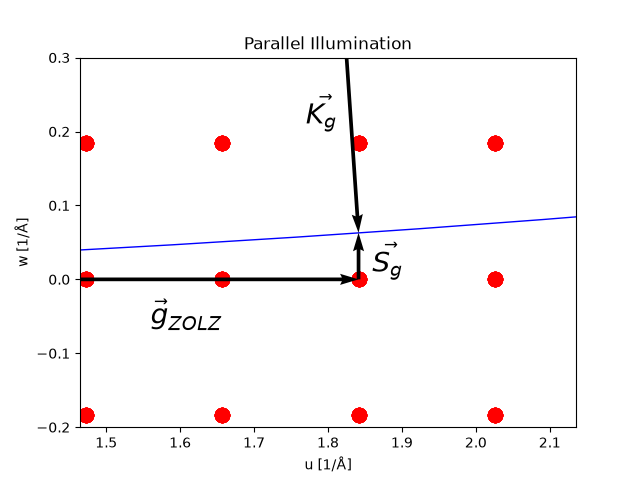

In [28]:
acceleration_voltage_V = 100.0 *1000.0 #V

wave_length_A  = pyTEMlib.utilities.get_wavelength(acceleration_voltage_V, unit='A')

print('The wavelength for {0:.1f}kV is : {1:.5f}pm'.format(acceleration_voltage_V/1000.,wave_length_A*100.))

K0_magnitude = 1/wave_length_A

Ewald_Sphere = plt.Circle((0, K0_magnitude), K0_magnitude, color='b', fill=False)

# Plot 2D
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(g[:,0], g[:,2], c='red',s=100)
ax.scatter(0, K0_magnitude, c='green',s=100)

ax.add_artist(Ewald_Sphere)

ax.quiver([0,0,0,g[2001,0]],[K0_magnitude,K0_magnitude,0,0],[0,g[2001,0],g[2001,0],0],[-K0_magnitude, -K0_magnitude+0.063,0,0.063], units='xy', scale =1, width = .005)

plt.text(1.86, .01,r'$\vec{S_g}$', size=20)
plt.text(1.56, -.06,r'$\vec{g}_{ZOLZ}$', size=20)
plt.text(1.77, .21,r'$\vec{K_g}$', size=20)
plt.text(.1,10,r'$\vec{K_0}$', size=20)
plt.title('Parallel Illumination')

ax.axis('equal')
plt.xlabel('u [1/Å]')
plt.ylabel('w [1/Å]')
ax.set_xlim(1.6,2.0)
ax.set_ylim(-.2,.3);

An excitation error vector pointing up (against the incoming vector $\vec{K_0}$) is defined as negative, one pointing down is positive.

### 2D Plot of Reciprocal Lattice with Excitation Error
The same plot as above but a little zoomed out will show also the incident wave vector.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


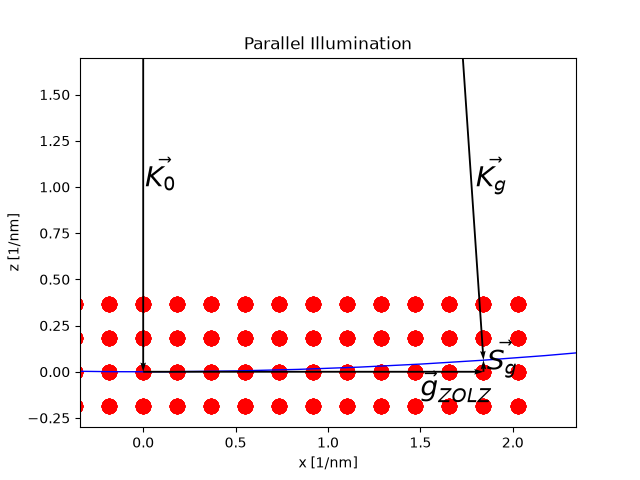

In [29]:
Ewald_Sphere = plt.Circle((0, K0_magnitude), K0_magnitude, color='b', fill=False)

# Plot 2D
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(g[:,0], g[:,2], c='red',s=100)
ax.scatter(0, K0_magnitude, c='green',s=100)

ax.add_artist(Ewald_Sphere)

ax.quiver([0,0,0,g[2001,0]],[K0_magnitude,K0_magnitude,0,0],[0,g[2001,0],g[2001,0],0],[-K0_magnitude, -K0_magnitude+0.063,0,0.063], units='xy', scale =1, width = .01)

plt.text(1.86, .01,r'$\vec{S_g}$', size=20)
plt.text(1.5, -.13,r'$\vec{g}_{ZOLZ}$', size=20)
plt.text(1.8, 1,r'$\vec{K_g}$', size=20)
plt.text(.01,1,r'$\vec{K_0}$', size=20)
plt.title('Parallel Illumination')

ax.axis('equal')
plt.xlabel('x [1/nm]')
plt.ylabel('z [1/nm]')
plt.xlim(0,2)
plt.ylim(-.3,1.7);

## Origin of Excitation Error
Part of the reason why we have an excitation error lays in the sample dimensions required for TEM investigations.

This influence of the sample geometry is further explored in these notebooks:
- [Relrod](CH2_06b-Relrod.ipynb)
- [Fourier Transform Laboratroy](CH2_06b-3D_FFT.ipynb)

## Center of Ewald Shere
So far we have considered the incident wave vector to be parallel to the Z-axis. 
However, we need to know the center of the Ewald sphere for any zone axis.


In [30]:
# INPUT
zone_hkl = np.array([1,1,0])

U0 = 0
for atom in atoms:
    U0 += pyTEMlib.diffraction_tools.get_form_factor(atom.symbol,0.0)*0.023933754

volume =  atoms.cell.volume  # Needs to be in Angstrom for form factors
AngstromConversion = 1.0e10  # So [1A (in m)] * AngstromConversion = 1
NanometerConversion = 1.0e9 

ScattFacToVolts=(scipy.constants.h**2)*(AngstromConversion**2)/(2*np.pi*scipy.constants.m_e*scipy.constants.e)*volume
U0=U0[0]*ScattFacToVolts
print(f'The inner potential is {U0/1000:.1f}kV')

incident_wave_vector_vacuum = 1/wave_length_A
K0_magnitude = incident_wave_vector = np.sqrt(1/wave_length_A**2 + U0 )#1/Ang

center_ewald = np.dot(zone_hkl,reciprocal_lattice)
center_ewald = center_ewald /np.linalg.norm(center_ewald)* incident_wave_vector
 
normal = zone_hkl/ np.linalg.norm(zone_hkl)
print('Center of Ewald sphere ',center_ewald)

The inner potential is 8.5kV
Center of Ewald sphere  [68.07196539 68.07196539  0.        ]


## Possible Reflections
must be within the excitation error to the Ewald sphere.

Find all Miller indices whose reciprocal point lays near the Ewald sphere with radius $K_0$  within a maximum excitation error $S_g$

with $S_g \approx (K_0^2 -|\vec{K_0}+\vec{g}|^2)/ 2K_0$

First we produce all Miller indices up to a maximum value of "hkl_max" and then we check whether they fullfil above condition.

Please change "hkl_max" and the maximum excitation error "Sg_max" and see what happens.

In [31]:
# INPUT 
hkl_max = 25  # maximum allowed Miller index
Sg_max = .01  # 1/nm  maximum allowed excitation error

h  = np.linspace(-hkl_max,hkl_max,2*hkl_max+1)   # all evaluated single Miller Indices
hkl  = np.array(list(itertools.product(h,h,h) )) # all evaluated Miller indices
g = np.dot(hkl,reciprocal_lattice)               # all evaluated reciprocal lattice points

# Calculate exitation errors for all reciprocal lattice points
S = []
for i  in range(len(g)):
    ## Zuo and Spence, 'Adv TEM', 2017 -- Eq 3:14
    S.append(float((K0_magnitude**2-np.linalg.norm(g[i] - center_ewald)**2)/(2*K0_magnitude)))
S = np.array(S)

# Determine reciprocal lattice points with excitation error less than the maximum allowed one: Sg_max
reflections = abs(S)< Sg_max

Sg = S[reflections]
g_hkl =g[reflections]
print(g_hkl.shape)
hkl = hkl[reflections]
 
print ('Of the {0} tested reciprocal lattice points, {1} have an excitation error less than {2:.2f} 1/nm'.format( len(g) , len(g_hkl), Sg_max))

(361, 3)
Of the 132651 tested reciprocal lattice points, 361 have an excitation error less than 0.01 1/nm


### All Possible and Allowed Reflections

see
- [Structure Factors](CH2_04-Structure_Factors.ipynb)
- [Kinematic Scattering Geometry](CH2_06-Kinematic_Scattering_Geometry.ipynb)
for details

Because the nuclei of the atoms in a material are positive, there is a small acceleration of the electron within the material.

We add this to the contribution to the magnitude of the incident wave-vector. 
The acceleration potential is called *inner potential* and is calculated from the scattering factors $f_e$ according to (Kirkland Eq 6.10:

$$U_{\vec{G}} =  \frac{h^2}{2 \pi m_e e} \frac{1}{V_{unit-cell}} \sum_j f_{e_j} (|\vec{G}|) \exp(-2\pi i \vec{G} \cdot \vec{r_j})$$ 
which reduces for $|\vec{G}| = 0$ to:

$$U_{0} =  \frac{h^2}{2 \pi m_e e} \frac{1}{V_{unit-cell}} \sum_j f_{e_j} (0)$$
 which forms an uniform potential inside the material


In [32]:
# --------------- INPUT ------------------------
zone_hkl = np.array([1, 1, 0])
hkl_max = 35  #  maximum allowed Miller index
Sg_max = 0.03   # 1/Ang  maximum allowed excitation error

acceleration_voltage_V = 200.0 * 1000.0 #V
# -------------------------------------------

#Initialize the dictionary with all the input
atoms = pyTEMlib.crystal_tools.structure_by_name('Silicon')
print(atoms)

#Reciprocal Lattice 
# We use the linear algebra package of numpy to invert the unit_cell "matrix"
reciprocal_unit_cell = atoms.cell.reciprocal()  # np.linalg.inv(atoms.cell).T # transposed of inverted unit_cell

wave_length_A = pyTEMlib.diffraction_tools.get_wavelength(acceleration_voltage_V, unit='A')

U_0 = 0  # in (Ang)
# atom form factor of zero reflection angle is the inner potential in 1/A
for atom in atoms:
    U_0 += pyTEMlib.diffraction_tools.get_form_factor(atom.symbol, 0.0)[0]
scattering_factor_to_volts = (scipy.constants.h*1e10)**2 / (2 * np.pi * scipy.constants.m_e * scipy.constants.e) / atoms.cell.volume

# Conversion of inner potential to Volts
U_0 =  U_0 * scattering_factor_to_volts

print('The inner potential is {0:.2f}V'.format(U_0))

incident_wave_vector_vacuum = 1/wave_length_A
K0_magnitude = incident_wave_vector = np.sqrt(1/wave_length_A**2 + U_0 )#1/Ang

cent = np.dot(zone_hkl,reciprocal_unit_cell)
cent = cent /np.linalg.norm(cent)* incident_wave_vector

# zone axis in global coordinate system
zone_vector = np.dot(zone_hkl,reciprocal_unit_cell)

h  = np.linspace(-hkl_max,hkl_max, 2*hkl_max+1)    # all evaluated single Miller Indices
hkl  = np.array(list(itertools.product(h, h, h) )) # all evaluated Miller indices
g = np.dot(hkl, reciprocal_unit_cell)              # all evaluated reciprocal lattice points

# Calculate excitation errors for all reciprocal lattice points
## Zuo and Spence, 'Adv TEM', 2017 -- Eq 3:14
S = (K0_magnitude**2-np.linalg.norm(g - cent, axis =1)**2)/(2*K0_magnitude)

# Determine reciprocal lattice points with excitation error less than the maximum allowed one: Sg_max
reflections = abs(S)< Sg_max

Sg = S[reflections]
g_hkl = g[reflections]
hkl = hkl[reflections] 
print ('Of the {0} tested reciprocal lattice points, {1} have an excitation error less than {2:.2f} 1/nm'.format( len(g) , len(g_hkl), Sg_max))

# Calculate Structure Factors

structure_factors = []


# ###
# Structure Factors
# ###
base = atoms.positions
for j  in range(len(g_hkl)):
    F = 0
    for atom in atoms:
        f = pyTEMlib.diffraction_tools.get_form_factor(atom.symbol, np.linalg.norm(g_hkl[j]))
        F += f * np.exp(-2*np.pi*1j*(g_hkl[j]*atom.position).sum())        
    structure_factors.append(F)
F = structure_factors = np.array(structure_factors)

allowed = np.absolute(structure_factors) > 0.000001

print(f'Of the {hkl.shape[0]} possible reflection {allowed.sum()} are allowed.')

# information of allowed reflections
allowed = allowed.squeeze()
Sg_allowed = Sg[allowed]
hkl_allowed = hkl[allowed][:]
g_allowed = g_hkl[allowed, :]
F_allowed = F[allowed]
intensities = np.absolute(F_allowed)**2 

# forbidden reflections:
forbidden = np.logical_not(allowed)
g_forbidden = g_hkl[forbidden, :]

# Determine Laue Zone for reflections
zone_axis = np.dot(zone_hkl, atoms.cell.array)
Laue_Zone = np.floor(abs(np.dot(hkl_allowed,zone_hkl)))# works only for cubic crystal systems
#Laue_Zone = np.floor(abs(np.dot(g_allowed,zone_axis)) ) # works for all crystal systems
ZOLZ = Laue_Zone ==0
HOLZ = Laue_Zone > 1

print ('Of those, there are {0} in ZOLZ and {1} in HOLZ'.format(ZOLZ.sum(),HOLZ.sum()))

intensities = np.absolute(F_allowed)**2 


Lattice(symbols='Si8', pbc=True, cell=[5.43088, 5.43088, 5.43088])
The inner potential is 13.90V
Of the 357911 tested reciprocal lattice points, 2109 have an excitation error less than 0.03 1/nm
Of the 2109 possible reflection 405 are allowed.
Of those, there are 57 in ZOLZ and 348 in HOLZ


## Plotting of Ewald Sphere

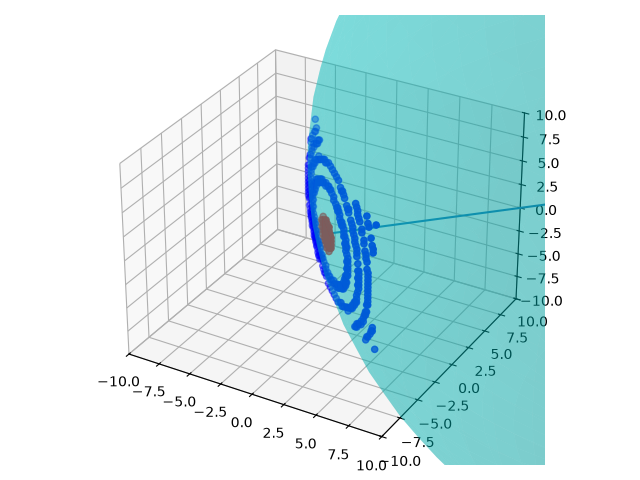

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(cent[0], cent[1], cent[2], c='green')
ax.plot((cent[0], 0), (cent[1], 0), (cent[2], 0)) 

# draw sphere
u, v = np.mgrid[0:2*np.pi:80j, 0:np.pi:40j]
x = np.cos(u)*np.sin(v)*K0_magnitude+cent[0]
y = np.sin(u)*np.sin(v)*K0_magnitude+cent[1]
z = np.cos(v)*K0_magnitude+cent[2]

ax.scatter(g_allowed[ZOLZ,0], g_allowed[ZOLZ,1], g_allowed[ZOLZ,2], c='red')
ax.scatter(g_allowed[HOLZ,0], g_allowed[HOLZ,1], g_allowed[HOLZ,2], c='blue')
ax.plot_surface( x, y, z,  rstride=1, cstride=1, color='c', alpha=0.3, linewidth=0)

ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-10, 10])
#ax.set_xlabel('scattering angle in (1/$\AA$)')
#ax.set_ylabel('scattering angle in (1/$\AA$)')
#ax.set_aspect("equal"); 
plt.tight_layout(); plt.show()

C:\Users\gduscher\AppData\Local\Temp\ipykernel_20076\221627313.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout();


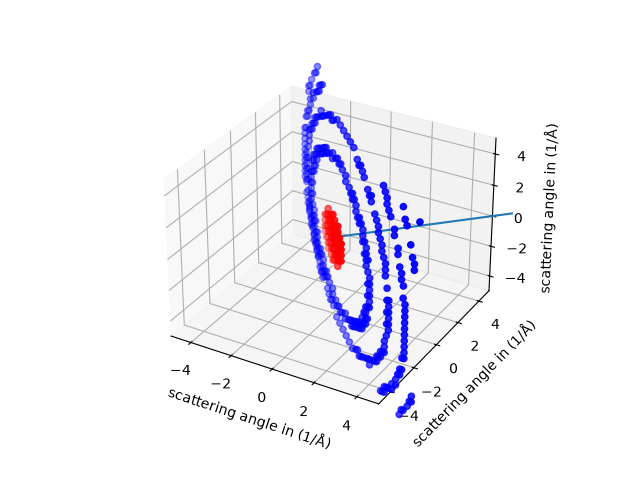

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(g_allowed[ZOLZ,0], g_allowed[ZOLZ,1], g_allowed[ZOLZ,2], c='red')
ax.scatter(g_allowed[HOLZ,0], g_allowed[HOLZ,1], g_allowed[HOLZ,2], c='blue')

ax.scatter(cent[0], cent[1], cent[2], c='green')
ax.plot((cent[0], 0), (cent[1], 0), (cent[2],0)) 
33
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
ax.set_zlim([-5, 5])
ax.set_xlabel('scattering angle in (1/Å)')
ax.set_ylabel('scattering angle in (1/Å)')
ax.set_zlabel('scattering angle in (1/Å)')

#ax.set_aspect("equal"); 
plt.tight_layout(); 
plt.show()

## Projection
We need to project the active reciprocal points onto the plane perpendicular to the zone axis.

For that we tilt the zone axis onto the z-axis

We use the spherical coordinates to determine the rotation matrix


In [36]:
def get_rotation_matrix(zone):
    
    #spherical coordinates of zone
    r = np.linalg.norm(zone)
    theta = np.arccos(zone[2]/r)
    if zone[0] < 0:
        theta = -theta
    if zone[0] == 0:
        phi= np.pi/2
    else: 
        phi = (np.arctan(zone[1]/zone[0]))

    print('Rotation theta ',np.degrees(theta),' phi ',np.degrees(phi))

    #first we rotate phi about z-axis
    c, s = np.cos(phi), np.sin(phi)
    rotz = np.array([[c, -s , 0],[s,c,0],[0,0,1]])

    # second we rotate theta about y-axis
    c, s = np.cos(theta), np.sin(theta)
    roty = np.array([[c, 0 ,s],[0,1,0],[-s,0,c]])
    
    # the rotation now makes z-axis coincide with plane normal
    return np.dot(rotz,roty), np.degrees(theta), np.degrees(phi)
# zone axis in global coordinate system

zone_vector = np.dot(zone_hkl,reciprocal_unit_cell)
rotation_matrix, theta, phi = get_rotation_matrix(zone_vector)

print(rotation_matrix)

print('\n Zone axis can now be rotated parallel to z axis')
print(np.dot(zone_vector,rotation_matrix))

Rotation theta  90.0  phi  45.0
[[ 4.32978028e-17 -7.07106781e-01  7.07106781e-01]
 [ 4.32978028e-17  7.07106781e-01  7.07106781e-01]
 [-1.00000000e+00  0.00000000e+00  6.12323400e-17]]

 Zone axis can now be rotated parallel to z axis
[1.59450412e-17 0.00000000e+00 2.60402285e-01]


### Rotation
We use the rotation matrix to rotate all lattice vectors

In [37]:
K0_vector_rotated = np.dot(cent, rotation_matrix)
cent_rotated = K0_vector_rotated
print(cent_rotated)

g_hkl_rotated = np.dot(g_allowed, rotation_matrix)

[2.45219702e-15 0.00000000e+00 4.00474164e+01]


Now we can plot these diffraction spots in 2D by just setting the z-coordinate to zero. That is our projection procedure.

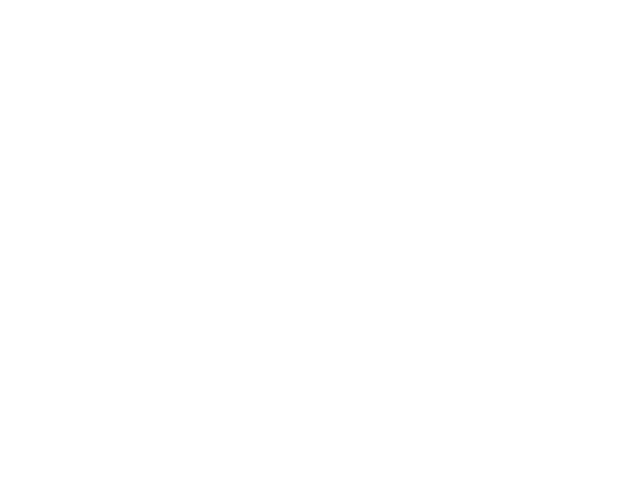

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(g_hkl_rotated[ZOLZ,0], g_hkl_rotated[ZOLZ,1], g_hkl_rotated[ZOLZ,2]+10, c='red')
ax.scatter(g_hkl_rotated[HOLZ,0], g_hkl_rotated[HOLZ,1], g_hkl_rotated[HOLZ,2]+10, c='blue')

ax.scatter(g_hkl_rotated[ZOLZ,0], g_hkl_rotated[ZOLZ,1], 0, c='red')
ax.scatter(g_hkl_rotated[HOLZ,0], g_hkl_rotated[HOLZ,1], 0, c='blue')

ax.set_xlim([-10,10])
ax.set_ylim([-10,10])
ax.set_zlim([0,12])
ax.set_xlabel('scattering angle in (1/Å)')
ax.set_ylabel('scattering angle in (1/Å)')
ax.set_zlabel('scattering angle in (1/Å)')

#ax.set_aspect("equal"); 
plt.tight_layout(); plt.show()

### Z-Component of Unit Cell

The Z-component of a projection can be derived from the radius of a HOLZ ring with pure trigonometry (choose the right triangles).

If $H$ is the distance between the reciprocal-lattice planes parallel to the beam and $G_n$ is the projected radius of a HOLZ ring, then 
$$
G_1 = \left( \frac{2H}{\lambda}\right)^{1/2} = \sqrt{\frac{2H}{\lambda}}\\
G_2 = 2\left( \frac{H}{\lambda}\right)^{1/2} = 2 \sqrt{\frac{H}{\lambda}}
$$
for FOLZ and SOLZ. 

With $\lambda$  wavelength of incident electrons

Similar expressions can be developed for higher order HOLZ rings.

In real space you get for example for FOLZ:
\begin{equation}
\frac{1}{H}=\frac{2}{\lambda G_1^2} = \frac{2}{\lambda} \left(\frac{\lambda L}{r}\right)^{2}
\end{equation}

If you did use a zone axis which is not ${100}$, then you have to compare your result to calculated values.

Assuming you are looking down $[UVW]$ then we know:
\begin{equation}
\frac{1}{H}= |[UVW]|
\end{equation}

Now we have to calculate this $|[UVW]|$ for different structures:\\
#### for fcc:
\begin{equation}
\frac{1}{H}= \frac{a_0}{p(U^2+V^2+W^2)}
\end{equation}
with $a_0$ is the lattice parameter and $p=1$ for $U+V+W$ is odd; $p=2$ for $U+V+W$ is even.


#### for bcc:
the same relationship as for fcc is true for bcc but $p$ is different:  $p=2$ for $U$, $V$, and $W$ all odd; $p=1$ otherwise.


Look up other crystal systems.

If a ring is forbidden: you have to multiply your measurement $1/H_m$ with an integer $n$ to obtain the distance of the crystal.


## Convergent Electron Diffraction Pattern
Because of the tilt cone of incident electron beams the spots with parallel illumination become disks.

<img src="images/cbed.png" alt="convergent beam electron diffraction" width="400" >

The location of the discs are given by kinematic diffraction theory, but like the selected area diffraction (SAD) pattern of parallel illumination the intensity is given by dynamic diffraction.

Each point in a disk has a different excitation error, so a convergent beam pattern can image the excitation errors direclty, if the diffraciton disks do not overlap. Where the disks overlap, interference pattern dominate. 

Using excitation errors results in the most precise (and most complicated) diffraction technique possible.



## Conclusion

The scattering geometry provides all the tools to determine which reciprocal lattice points are possible and which of them are allowed and which are forbidden. Now we need to explore dynamic diffraction.

